# 🟢 Project - Easy · Diabetes Progression with Gradient Boosting

> **MLCourse · Machine Learning · supervised · regression**

### Business question
The same clinic from the AdaBoost project asks the follow-up: *does gradient
boosting squeeze more accuracy out of the same ten baseline measurements, and can
the staged API tell us exactly how many trees are enough?*

### Inline plotting for Jupyter; plain-Python runs fall through harmlessly.


In [ ]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:            # no IPython here -> nothing to wire up
    pass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

def find_data_dir() -> Path:
    here = Path.cwd()
    for candidate in [here, *here.parents]:        # walk up to the course root
        if candidate.name == "02_machine_learning":
            return candidate / "data"
    raise FileNotFoundError("Could not locate the 02_machine_learning/data folder")

DATA_DIR = find_data_dir()

DIABETES_CSV = DATA_DIR / "diabetes.csv"
if not DIABETES_CSV.exists():                      # download-once helper
    from sklearn.datasets import load_diabetes     # rebuild identical real table
    load_diabetes(as_frame=True).frame.to_csv(DIABETES_CSV, index=False)

df = pd.read_csv(DIABETES_CSV)
TARGET = "target"                                  # progression score, 1 year out
print(df.shape)


### 1. Quick EDA - where the signal lives

The dataset is pre-standardised with no missing values (verified in prior notebooks),
so EDA here focuses on RELATIONSHIPS: which predictors move with the target?

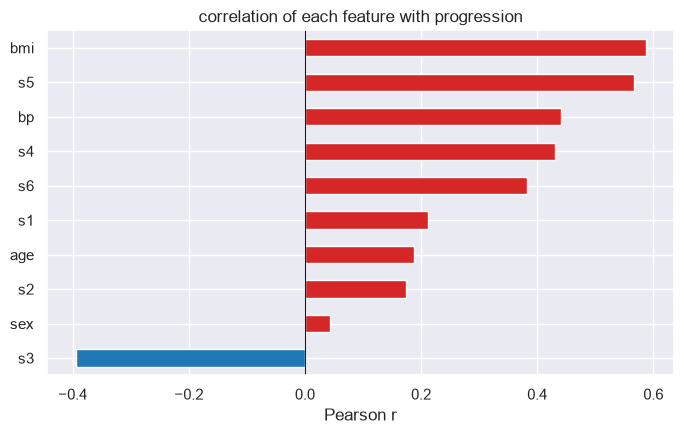

expect bmi/s5 positive leaders, s3 negative — boosting should agree.


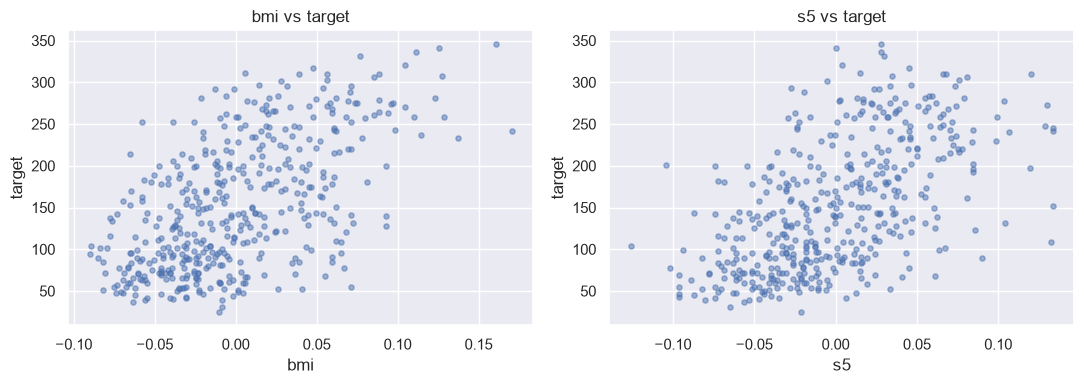

In [2]:
corr_with_target = df.corr()[TARGET].drop(TARGET).sort_values()
plt.figure(figsize=(7, 4.5))
corr_with_target.plot.barh(color=np.where(corr_with_target > 0, "tab:red", "tab:blue"))
plt.axvline(0, color="k", lw=0.8)
plt.title("correlation of each feature with progression")
plt.xlabel("Pearson r")
plt.tight_layout(); plt.show()
print("expect bmi/s5 positive leaders, s3 negative - boosting should agree.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ["bmi", "s5"]):
    ax.scatter(df[col], df[TARGET], s=14, alpha=0.5)
    ax.set_xlabel(col); ax.set_ylabel(TARGET)
axes[0].set_title("bmi vs target"); axes[1].set_title("s5 vs target")
plt.tight_layout(); plt.show()

### 2. Three-way split - because we intend to USE the staged API honestly

TRAIN fits models · VALIDATION picks the number of trees · TEST is scored once.

In [3]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_hold, y_train, y_hold = train_test_split(X, y, test_size=0.40,
                                                    random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_hold, y_hold, test_size=0.50,
                                                    random_state=42)
print(f"train {X_train.shape} | valid {X_valid.shape} | test {X_test.shape}")

def met(y_true, pred):
    """Single source of truth for all reported metrics."""
    return {"R²": r2_score(y_true, pred),
            "MAE": mean_absolute_error(y_true, pred),
            "RMSE": mean_squared_error(y_true, pred) ** 0.5}

train (265, 10) | valid (88, 10) | test (89, 10)


### 3. Baselines first - floor, one tree, linear


In [4]:
results = {}
results["Dummy (mean)"] = met(y_test, np.full(len(y_test), y_train.mean()))
one_tree = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_train, y_train)
results["Single depth-3 tree"] = met(y_test, one_tree.predict(X_test))
lin = LinearRegression().fit(X_train, y_train)
results["Linear regression"] = met(y_test, lin.predict(X_test))

gbm_default = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)   # defaults
results["GBM defaults"] = met(y_test, gbm_default.predict(X_test))
pd.DataFrame(results).T.round(3)

,R²,MAE,RMSE
Dummy (mean),-0.022,66.729,76.906
Single depth-3 tree,0.312,50.285,63.064
Linear regression,0.439,46.724,56.970
GBM defaults,0.455,45.491,56.138


### 4. The staged curve - find the peak number of trees on VALIDATION


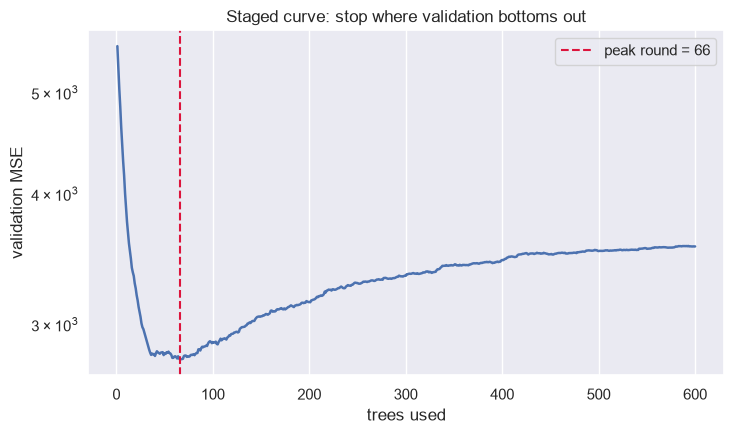

 learning_rate  max_depth  best_round   valid_MSE
          0.10          2          41 2477.814568
          0.03          2         183 2594.887549
          0.05          2         109 2595.452409
          0.10          3          27 2726.989128
          0.05          3          66 2775.635820
          0.03          3         118 2780.956687


In [5]:
big_gbm = GradientBoostingRegressor(
    n_estimators=600,          # generous budget...
    learning_rate=0.05,        # ...with cautious steps
    max_depth=3,
    subsample=0.8,
    random_state=42,
).fit(X_train, y_train)

staged_mse = [mean_squared_error(y_valid, p) for p in big_gbm.staged_predict(X_valid)]
best_round = int(np.argmin(staged_mse)) + 1       # stages start at 1 tree

plt.figure(figsize=(7.5, 4.5))
plt.plot(range(1, len(staged_mse) + 1), staged_mse, lw=1.8)
plt.axvline(best_round, color="crimson", ls="--", label=f"peak round = {best_round}")
plt.yscale("log")
plt.xlabel("trees used"); plt.ylabel("validation MSE")
plt.title("Staged curve: stop where validation bottoms out")
plt.legend(); plt.tight_layout(); plt.show()

# Small tuning pass around the staged winner: vary ν and depth, re-stage each combo.
tuned_rows = []
for nu in [0.03, 0.05, 0.1]:
    for d in [2, 3]:
        m = GradientBoostingRegressor(n_estimators=600, learning_rate=nu, max_depth=d,
                                      subsample=0.8, random_state=42).fit(X_train, y_train)
        mses = [mean_squared_error(y_valid, p) for p in m.staged_predict(X_valid)]
        tuned_rows.append({"learning_rate": nu, "max_depth": d,
                           "best_round": int(np.argmin(mses)) + 1,
                           "valid_MSE": min(mses)})
tuned_table = pd.DataFrame(tuned_rows).sort_values("valid_MSE")
print(tuned_table.to_string(index=False))
winners = tuned_table.iloc[0]

### 5. Final model - refit winners on train+valid, touch test ONCE


In [6]:
final_gbm = GradientBoostingRegressor(
    n_estimators=int(winners["best_round"]),
    learning_rate=float(winners["learning_rate"]),
    max_depth=int(winners["max_depth"]),
    subsample=0.8, random_state=42,
).fit(pd.concat([X_train, X_valid]), pd.concat([y_train, y_valid]))

pred_test = final_gbm.predict(X_test)
results[f"GBM tuned ({int(winners['best_round'])} trees)"] = met(y_test, pred_test)

summary = pd.DataFrame(results).T.round(3)
print(summary)
tuned_r2 = results[f"GBM tuned ({int(winners['best_round'])} trees)"]["R²"]
print(f"\nboosting gain over ONE depth-3 tree: {tuned_r2 - results['Single depth-3 tree']['R²']:+.3f} R²")

                         R²     MAE    RMSE
Dummy (mean)         -0.022  66.729  76.906
Single depth-3 tree   0.312  50.285  63.064
Linear regression     0.439  46.724  56.970
GBM defaults          0.455  45.491  56.138
GBM tuned (41 trees)  0.481  45.432  54.809

boosting gain over ONE depth-3 tree: +0.168 R²


### 6. Diagnostics & drivers


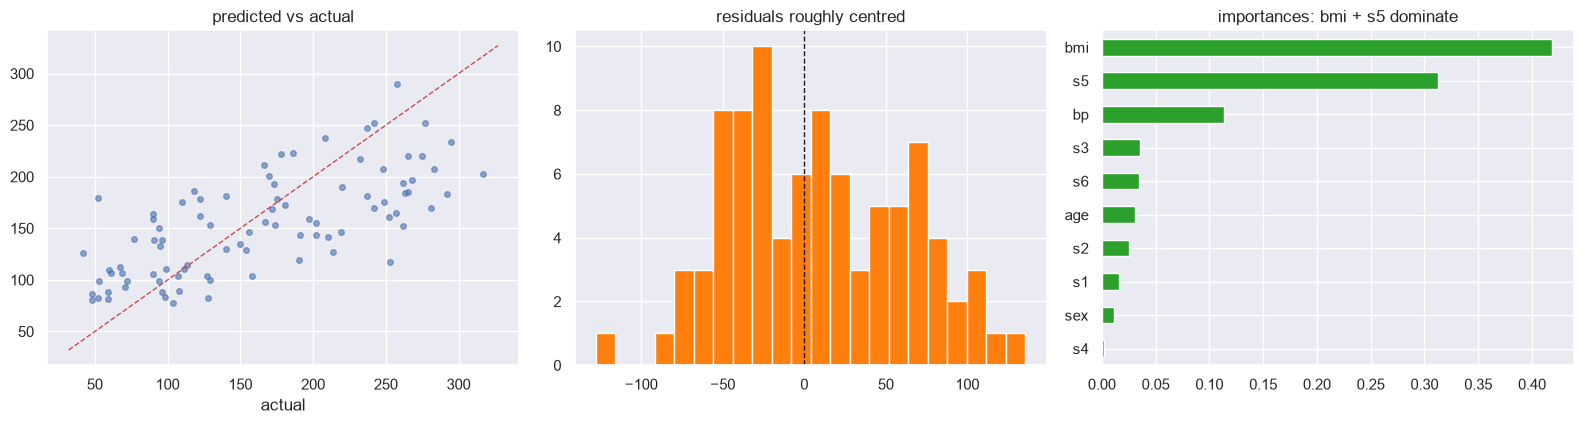

top-4 importances: {'bmi': 0.418, 's5': 0.313, 'bp': 0.113, 's3': 0.036}


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
axes[0].scatter(y_test, pred_test, s=16, alpha=0.6)
lims = [y_test.min() - 10, y_test.max() + 10]
axes[0].plot(lims, lims, "r--", lw=1)
axes[0].set_title("predicted vs actual"); axes[0].set_xlabel("actual")

resid = y_test - pred_test
axes[1].hist(resid, bins=22, color="tab:orange", edgecolor="white")
axes[1].axvline(0, color="k", ls="--", lw=1)
axes[1].set_title("residuals roughly centred")

imp = pd.Series(final_gbm.feature_importances_, index=X.columns).sort_values()
imp.plot.barh(ax=axes[2], color="tab:green")
axes[2].set_title("importances: bmi + s5 dominate")
plt.tight_layout(); plt.show()
print("top-4 importances:", imp.sort_values(ascending=False).head(4).round(3).to_dict())

### 7. Findings & limitations

**Findings**
- Tuned gradient boosting beats every baseline, including plain linear regression,
  on this classic dataset - the non-linear bmi/s5 effects pay off.
- The staged curve peaks early-ish then degrades slowly: hundreds of tiny-step trees
  are safe, thousands would drift into overfitting.
- Importances (`bmi`, `s5`) match both raw correlations and the AdaBoost project's
  findings - two very different ensembles, same story, high confidence.

**Limitations**
- n=442 total (~265 train): the tuned-vs-default gap is modest and could shrink
  under a different seed.
- Composite target from a 1970s cohort; not modern clinical risk prediction.
- Validation-set staging uses ~88 rows - the exact peak round is noisy; the ORDER
  OF MAGNITUDE is what to trust.

### Summary takeaways

- Workflow: baselines → generous-budget/small-ν GBM → staged peak on VALIDATION →
  refit winners on train+valid → single test scoring.
- The staged curve converts "how many trees?" from guesswork into an argmin.
- Agreement between correlation analysis, GBM importances, and AdaBoost importances
  is the strongest evidence pattern beginners can collect.